In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/students_mental_health_survey_augmented_10000_with_burnout.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,...,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type,burnout_composite_score,burnout,burnout_raw_score
0,29,Medical,Female,3.69,5,0,3,Good,Low,Average,...,Never,No,No,4,Moderate,20,On-Campus,0.199412,0,2.666667
1,24,Business,Female,3.75,1,3,0,Good,Low,Average,...,Never,No,No,1,High,25,On-Campus,-0.610848,0,1.333333
2,25,Engineering,Male,3.15,3,2,4,Good,Moderate,Average,...,Never,Yes,No,2,Moderate,21,Off-Campus,0.408598,0,3.000000
3,18,Law,Male,3.97,1,1,5,Poor,Moderate,Average,...,Occasionally,No,No,0,Moderate,28,With Family,0.001607,0,2.333333
4,25,Law,Female,3.13,4,3,5,Average,Moderate,Average,...,Occasionally,No,No,5,Moderate,26,On-Campus,1.021761,1,4.000000


In [ ]:
# Convert to numeric classes
df["burnout_class"] = pd.cut(
    df["burnout_raw_score"],
    bins=[0, 1.66, 3.33, 5],
    labels=[0, 1, 2],
    include_lowest=True
).astype(int)

print(df)

      Age            Course  Gender  CGPA  Stress_Level  Depression_Score  \
0      29           Medical  Female  3.69             5                 0   
1      24          Business  Female  3.75             1                 3   
2      25       Engineering    Male  3.15             3                 2   
3      18               Law    Male  3.97             1                 1   
4      25               Law  Female  3.13             4                 3   
...   ...               ...     ...   ...           ...               ...   
9995   20          Business    Male  3.51             0                 3   
9996   23           Medical    Male  3.40             4                 5   
9997   23  Computer Science    Male  3.91             1                 4   
9998   22            Others  Female  3.66             5                 0   
9999   18               Law    Male  3.43             1                 3   

      Anxiety_Score Sleep_Quality Physical_Activity Diet_Quality  ...  \
0 

In [ ]:
df.columns

Index(['Age', 'Gender', 'CGPA', 'Stress_Level', 'Depression_Score',
       'Anxiety_Score', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality',
       'Social_Support', 'Relationship_Status', 'Substance_Use',
       'Counseling_Service_Use', 'Family_History', 'Chronic_Illness',
       'Financial_Stress', 'Extracurricular_Involvement',
       'Semester_Credit_Load', 'Residence_Type', 'burnout_composite_score',
       'burnout', 'burnout_raw_score', 'burnout_class',
       'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
# 4️⃣ Identify categorical columns automatically
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# 5️⃣ Convert all categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Categorical columns to encode: ['Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']


In [ ]:
df.columns

Index(['Age', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score',
       'Financial_Stress', 'Semester_Credit_Load', 'burnout_composite_score',
       'burnout', 'burnout_raw_score', 'burnout_class',
       'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others', 'Gender_Male', 'Sleep_Quality_Good',
       'Sleep_Quality_Poor', 'Physical_Activity_Low',
       'Physical_Activity_Moderate', 'Diet_Quality_Good', 'Diet_Quality_Poor',
       'Social_Support_Low', 'Social_Support_Moderate',
       'Relationship_Status_Married', 'Relationship_Status_Single',
       'Substance_Use_Never', 'Substance_Use_Occasionally',
       'Counseling_Service_Use_Never', 'Counseling_Service_Use_Occasionally',
       'Family_History_Yes', 'Chronic_Illness_Yes',
       'Extracurricular_Involvement_Low',
       'Extracurricular_Involvement_Moderate', 'Residence_Type_On-Campus',
       'Residence_Type_With Family'],
      dtype='object')

In [ ]:
import numpy as np

# Function to impute using stochastic hot-deck
def stochastic_hotdeck(series):
    missing_idx = series[series.isna()].index
    observed_values = series.dropna().values
    # Randomly sample from observed values
    series.loc[missing_idx] = np.random.choice(observed_values, size=len(missing_idx), replace=True)
    return series

# Apply to all columns
for col in df.columns:
    df[col] = stochastic_hotdeck(df[col])

/tmp/ipykernel_272/4060334354.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[missing_idx] = np.random.choice(observed_values, size=len(missing_idx), replace=True)
/tmp/ipykernel_272/4060334354.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[missing_idx] = np.random.choice(observed_values, size=len(missing_idx), replace=True)
/tmp/ipykernel_272/4060334354.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

In [ ]:
X = df[['Age', 'CGPA',
       'Financial_Stress', 'Semester_Credit_Load',  'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others', 'Gender_Male', 'Sleep_Quality_Good',
       'Sleep_Quality_Poor', 'Physical_Activity_Low',
       'Physical_Activity_Moderate', 'Diet_Quality_Good', 'Diet_Quality_Poor',
       'Social_Support_Low', 'Social_Support_Moderate',
       'Relationship_Status_Married', 'Relationship_Status_Single',
       'Substance_Use_Never', 'Substance_Use_Occasionally',
       'Counseling_Service_Use_Never', 'Counseling_Service_Use_Occasionally',
       'Family_History_Yes', 'Chronic_Illness_Yes',
       'Extracurricular_Involvement_Low',
       'Extracurricular_Involvement_Moderate', 'Residence_Type_On-Campus',
       'Residence_Type_With Family']]

y = df["burnout_class"]


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic regression model
model = LogisticRegression(multi_class="multinomial", max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predict class for each row
predictions = model.predict(X_test)

# Evaluate model
print(classification_report(y_test, predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       394
           1       0.62      1.00      0.77      1246
           2       0.00      0.00      0.00       360

    accuracy                           0.62      2000
   macro avg       0.21      0.33      0.26      2000
weighted avg       0.39      0.62      0.48      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Working BaseLine LR Model below

In [ ]:
X = df[['Age', 'CGPA',
       'Financial_Stress', 'Semester_Credit_Load',  'Course_Computer Science', 'Course_Engineering', 'Course_Law',
       'Course_Medical', 'Course_Others', 'Gender_Male', 'Sleep_Quality_Good',
       'Sleep_Quality_Poor', 'Physical_Activity_Low',
       'Physical_Activity_Moderate', 'Diet_Quality_Good', 'Diet_Quality_Poor',
       'Social_Support_Low', 'Social_Support_Moderate',
       'Relationship_Status_Married', 'Relationship_Status_Single',
       'Substance_Use_Never', 'Substance_Use_Occasionally',
       'Counseling_Service_Use_Never', 'Counseling_Service_Use_Occasionally',
       'Family_History_Yes', 'Chronic_Illness_Yes',
       'Extracurricular_Involvement_Low',
       'Extracurricular_Involvement_Moderate', 'Residence_Type_On-Campus',
       'Residence_Type_With Family']]

y = df["burnout_class"]


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# Predict class for each row
predictions = model.predict(X_test)

# Evaluate model
print(classification_report(y_test, predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.24      0.43      0.31       394
           1       0.66      0.12      0.21      1246
           2       0.21      0.61      0.31       360

    accuracy                           0.27      2000
   macro avg       0.37      0.39      0.28      2000
weighted avg       0.49      0.27      0.25      2000



### ConfusionMatrix are below

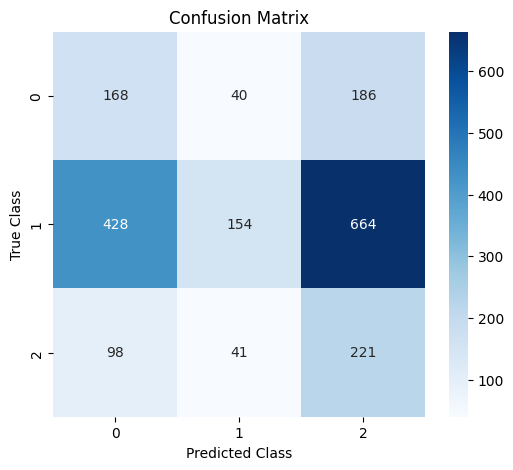

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

class_names = [0, 1, 2]

# Display as a heatmap with seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

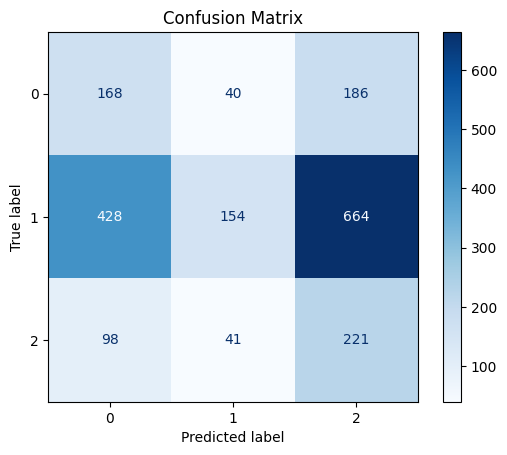

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

### ConfusionMatrix as percentages below

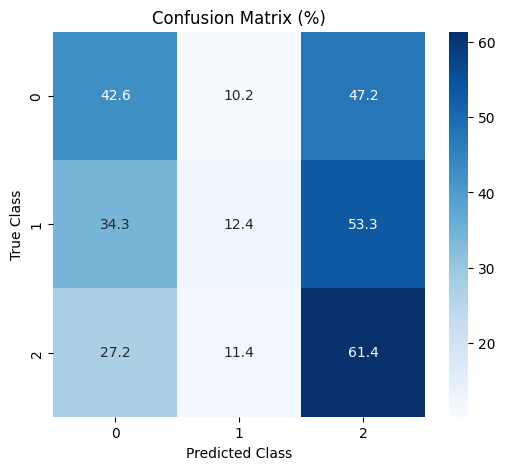

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

# Normalize row-wise to get percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Class labels
class_names = [0, 1, 2]

# Plot as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (%)")
plt.show()

### Showing why I balanced classes in model

In [ ]:
(df['burnout_class'] == 0).sum()

np.int64(1890)

In [ ]:
(df['burnout_class'] == 1).sum()

np.int64(6228)

In [ ]:
(df['burnout_class'] == 2).sum()

np.int64(1882)

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold


In [ ]:
# Logistic Regression with class weighting for imbalance
model = LogisticRegression(multi_class="multinomial", max_iter=1000, class_weight="balanced")

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation with multiple scoring metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)

# Display results
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores}")
    print(f"Mean {metric}: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}\n")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

accuracy: [0.2635 0.281  0.275  0.274  0.292 ]
Mean accuracy: 0.2771, Std: 0.0093

precision_macro: [0.3459582  0.35084423 0.35563595 0.34306892 0.35775253]
Mean precision_macro: 0.3507, Std: 0.0056

recall_macro: [0.3760644  0.37859053 0.39393156 0.39228275 0.39700385]
Mean recall_macro: 0.3876, Std: 0.0085

f1_macro: [0.26798023 0.28417633 0.28049548 0.27907396 0.29489872]
Mean f1_macro: 0.2813, Std: 0.0087

